## Basics of ML model and Gradient Descent

In this Notebook we will try to implement a simple **2nd Degree Polynomial Regression Model** while learning gradient Descent. <br>We will follow this model :- 
<br><br><img src="../data/model.png" alt="Description" width="800" height="500">


## Importing the necessary packages
- Nympy : For numerecal Processing
- Pandas : For handaling data files
- sklearn : various tools for data, preprocessing and model training
- matplotlib : for generating graphs needed for our model

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Loading and viewing the data

In [2]:
df = pd.read_csv("../data/dummy.csv")
df.head()

,Brightness Level,Power Consumed
0,1.000000,7.028105
1,1.045226,4.256111
2,1.090452,5.371115
3,1.135678,7.855312
4,1.180905,7.070575


plotting scatterplot with our data

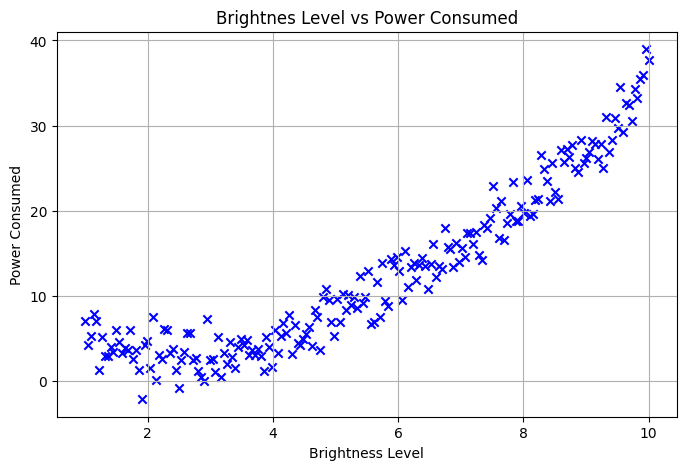

In [3]:
plt.figure(figsize=(8,5))
plt.scatter(df["Brightness Level"], df["Power Consumed"], color="blue", marker = "x")
plt.title("Brightnes Level vs Power Consumed")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.grid(True)

We will not use all the available data for training purpose.<br> We have to keep a small fraction of data for evaluation. <br>For that reason we will use ***train_test_split()*** function to split our data into training and testing part

In [4]:
x_train, x_test, y_train, y_test = train_test_split(df["Brightness Level"].to_numpy(dtype=float), df["Power Consumed"].to_numpy(dtype=float), test_size=0.2, random_state=42)
print(f"Shape of training inp features : {x_train.shape}")
print(f"Shape of testing inp features : {x_test.shape}")

Shape of training inp features : (160,)
Shape of testing inp features : (40,)


## Building the Model
we will split the model into following blocks :- <br>
- parameters : numpy array
- prediction : function
- cost function : function
- Gradient Descent : function

### 1. Parameters

**Initialization of parameters :-**<br>
There is no single rule to initialize parameters but we do have some common practices :-<br>
1. Initializing all parameters to 0
2. Assaigning our own parameters ( *Our current focus*)
3. Random Initialization (*Best practice*)

In [6]:
parameters = np.array([0.015,0.5,0.4])

lets visualize the model with current parameters

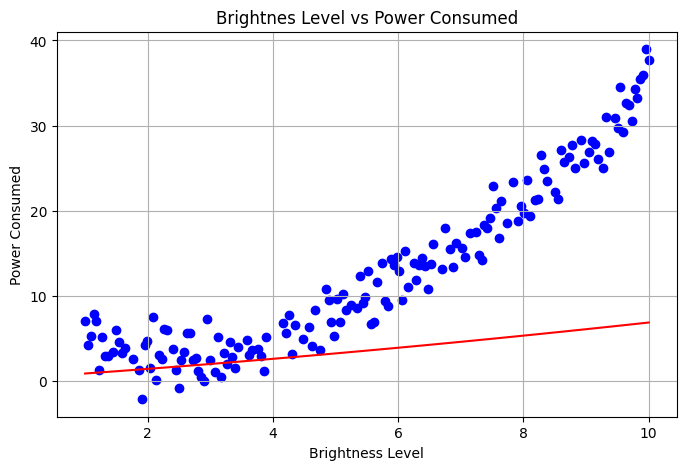

In [7]:
plt.figure(figsize=(8,5))
plt.scatter(x_train, y_train, color="blue")
plt.plot(np.linspace(1,10,100), parameters[0] * np.linspace(1,10,100) **2 + parameters[1]*np.linspace(1,10,100) + parameters[2], color = "red")
plt.title("Brightnes Level vs Power Consumed")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.grid(True)

### Prediction Function

**Structure :**<br>
`function parameters : inp_feature_x (numpy array), params (numpy array)`<br>
`function return : predicted_output_labels (numpy array)`

**Linear Combination**<br>
$y_p = w_{1} x^2 + w_{2} x + b$<br>
*here w1 = `params[0]`, w2 = `params[1]` and b = `params[2]`*

In [9]:
def predict(x:np.array, params:np.array):
    y_pred = None
    #Begin Your Code Here
    y_pred = params[0] * x**2 + params[1] * x + params[2]
    #End Your Code here
    return y_pred

lets predict the labels with our predict function

In [10]:
print(pd.DataFrame({"BrightNess Level": x_train[:5], "Power Consumed (True)":y_train[:5],"Power Consumed (Predicted)":predict(x_train[:5], parameters)}))

   BrightNess Level  Power Consumed (True)  Power Consumed (Predicted)
0          4.572864               6.422146                    3.000098
1          9.909548              35.927481                    6.827761
2          2.718593               2.483534                    1.870158
3          2.085427               7.543158                    1.507949
4          6.517588              13.800777                    4.295978


### Cost Function

we are using Mean Square Error as cost function which is :- <br><br>
$j (w_1, w_2, b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$

**Structure :**<br>
`Function Parameters : inp_feature_x (numpy array),output_labels_y (numpy array) ,params (numpy array)`<br>
`Function Return : Mean_squared_error (float)`


In [12]:
def compute_cost(x:np.array, y:np.array, params:np.array):
    cost = 0
    n = x.shape[0]
    #Begin Your Code Here
    y_pred = predict(x,params)
    cost = (1 /n) * np.sum((y - y_pred)**2)
    cost = np.mean((y - y_pred)**2)
    #End Your Code here
    return cost

lets compute cost with our current parameters

In [13]:
print(f"Mean Squared Error : {compute_cost(x_train,y_train,parameters)}")

Mean Squared Error : 155.5542576770968


### Gradient Descent

we have already computed the gradient for all 3 parameters as :- <br><br>
$\frac{\partial j}{\partial b} = \frac{-2}{n} \sum_{i=1}^{n} (y_i - y_p)$<br><br>
$\frac{\partial j}{\partial w_2} = \frac{-2}{n} \sum_{i=1}^{n} (y_i - y_p)x$<br><br>
$\frac{\partial j}{\partial w_1} = \frac{-2}{n} \sum_{i=1}^{n} (y_i - y_p)x^2$<br><br>

now lets write a function to compute gradients for each parameters :- <br>
**Structure :**<br>
`Function Parameters : inp_feature_x (numpy array),output_labels_y (numpy array) ,params (numpy array)`<br>
`Function Return : gradients (numpy array)`

***Note: The position of gradients in array should be equivalent to positions of parameters in their array. For e.g, b is in index 2 in `parameters` then gradient of b should in in same index in `gradients`***

In [21]:
def compute_gradients(x:np.array, y:np.array, params:np.array):
    gradients = np.array([0,0,0])
    n = x.shape[0]
    #Begin Your Code Here
    y_pred = predict(x,params)
    gradients[0] =  (-2/n) * np.sum((y - y_pred) * (x ** 2))
    gradients[1] =  (-2/n) * np.sum((y - y_pred) * x)
    gradients[2] =  (-2/n) * np.sum((y - y_pred))
    #End Your Code here
    return gradients


lets compute gradients

In [22]:
print(pd.DataFrame({"Parameters":parameters, "Gradients":compute_gradients(x_train, y_train, parameters)}))

   Parameters  Gradients
0       0.015      -1167
1       0.500       -141
2       0.400        -18


we have successfully implemented gradient computation,now lets create a function for gradient descent<br>
updating the parameters :- <br>

$param_{new} = param_{old} - \alpha \frac{\partial j}{\partial param}$

In Our case:- <br>

$w_1 = w_1 - \alpha \frac{\partial j}{\partial w_1}$

$w_2 = w_2 - \alpha \frac{\partial j}{\partial w_2}$

$b = b - \alpha \frac{\partial j}{\partial b}$

**Structure :**<br>
`Function Parameters : inp_feature_x (numpy array),output_labels_y (numpy array) ,params (numpy array)`<br>
`Default Parameters : epoch = 1000, alpha = 0.0001` <br>
`Function Return : new_parameters (numpy array)`

In [ ]:
def gradient_descent(x:np.array, y:np.array, params:np.array, epoch = 1000, alpha = 0.0001):
    #Begin code here
    for i in range(epoch):
        grad = compute_gradients(x,y,params)
        params -= alpha * grad
        if i%50 == 0:
            cost = compute_cost(x,y,params)
            print(f"epoch = {i+1}\t Cost = {round(float(cost),2)}\t params = {[float(round(i,2)) for i in params]}")
    #End code here
    print(f"epoch = {i+1}\t Cost = {round(float(cost),2)}\t params = {[float(round(i,2)) for i in params]}")
    return params


lets look at our model after 1st iteration

In [ ]:
new_params = gradient_descent(x_train, y_train, parameters,epoch=1)

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(x_train, y_train, color="blue")
plt.plot(np.linspace(1,10,100), new_params[0] * np.linspace(1,10,100) **2 + new_params[1]*np.linspace(1,10,100) + new_params[2], color = "red")
plt.title("Brightnes Level vs Power Consumed")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.grid(True)

lets train our model over 1000 epoch

In [ ]:
parameters = gradient_descent(x_train, y_train, parameters)


In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(x_train, y_train, color="blue")
plt.plot(np.linspace(1,10,100), parameters[0] * np.linspace(1,10,100) **2 + parameters[1]*np.linspace(1,10,100) + parameters[2], color = "red")
plt.title("Brightnes Level vs Power Consumed")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.grid(True)

## Evaluation of our Model
Lets test our model with data we have not trained with. <br>
we will calculate MSE of test data and compare it with MSE of trained data

In [ ]:
print(f"MSE of training set = {compute_cost(x_train,y_train,parameters)}")
print(f"MSE of training set = {compute_cost(x_test,y_test,parameters)}")

visualization of model in test set

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(x_test, y_test, color="blue")
plt.plot(np.linspace(1,10,100), parameters[0] * np.linspace(1,10,100) **2 + parameters[1]*np.linspace(1,10,100) + parameters[2], color = "red")
plt.title("Brightnes Level vs Power Consumed")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.grid(True)